In [1]:
#GA and NM Hybrid-----Santiago

In [2]:
#Logarithmic

Generation 1, Best Fitness: 0.5974722578448178
Generation 2, Best Fitness: 0.6079562879504691
Generation 3, Best Fitness: 0.6125655821666652
Generation 4, Best Fitness: 0.6125655821666652
Generation 5, Best Fitness: 0.622215183653215
Generation 6, Best Fitness: 0.622215183653215
Generation 7, Best Fitness: 0.6303116901659017
Generation 8, Best Fitness: 0.6303116901659017
Generation 9, Best Fitness: 0.6428929578143616
Generation 10, Best Fitness: 0.6428929578143616
Generation 11, Best Fitness: 0.6488754483104962
Generation 12, Best Fitness: 0.6488754483104962
Generation 13, Best Fitness: 0.6509938755960075
Generation 14, Best Fitness: 0.6549433613225928
Generation 15, Best Fitness: 0.6560648496585109
Generation 16, Best Fitness: 0.6597617554104032
Generation 17, Best Fitness: 0.6597617554104032
Generation 18, Best Fitness: 0.6701117743488294
Generation 19, Best Fitness: 0.6703852761894348
Generation 20, Best Fitness: 0.6734935723493005
Generation 21, Best Fitness: 0.6843108068384657
Gen

<Figure size 1200x800 with 0 Axes>

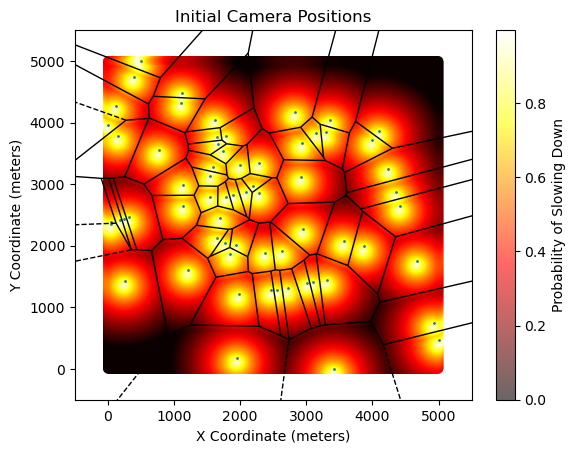

Initial Average Coverage Probability: 0.4264971596581007


<Figure size 1200x800 with 0 Axes>

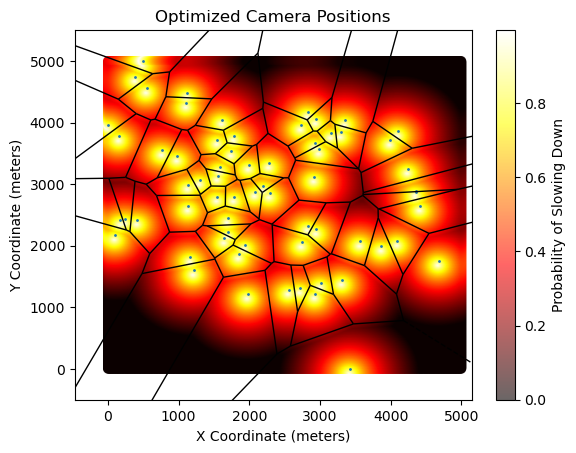

Optimized Average Coverage Probability: 0.4921390108421023

Solution Improvement: 0.15390923408874066


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_4331/3246414304.py:296: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.5093017287708319


<Figure size 1200x800 with 0 Axes>

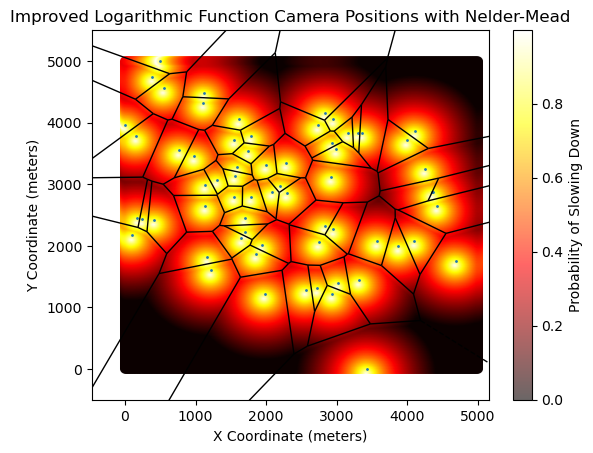

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.67, Y: -33.44)
Camera 2: (X: -70.66, Y: -33.45)
Camera 3: (X: -70.65, Y: -33.44)
Camera 4: (X: -70.65, Y: -33.44)
Camera 5: (X: -70.67, Y: -33.44)
Camera 6: (X: -70.65, Y: -33.44)
Camera 7: (X: -70.66, Y: -33.44)
Camera 8: (X: -70.66, Y: -33.44)
Camera 9: (X: -70.65, Y: -33.44)
Camera 10: (X: -70.66, Y: -33.43)
Camera 11: (X: -70.66, Y: -33.44)
Camera 12: (X: -70.64, Y: -33.45)
Camera 13: (X: -70.67, Y: -33.45)
Camera 14: (X: -70.67, Y: -33.43)
Camera 15: (X: -70.65, Y: -33.45)
Camera 16: (X: -70.66, Y: -33.45)
Camera 17: (X: -70.66, Y: -33.44)
Camera 18: (X: -70.63, Y: -33.45)
Camera 19: (X: -70.66, Y: -33.46)
Camera 20: (X: -70.65, Y: -33.46)
Camera 21: (X: -70.66, Y: -33.45)
Camera 22: (X: -70.66, Y: -33.46)
Camera 23: (X: -70.66, Y: -33.44)
Camera 24: (X: -70.66, Y: -33.45)
Camera 25: (X: -70.64, Y: -33.47)
Camera 26: (X: -70.63, Y: -33.45)
Camera 27: (X: -70.64, Y: -33.44)
Camera 28: (X: -70.64, Y: -33.44)
Camera 29: (X

<Figure size 1200x800 with 0 Axes>

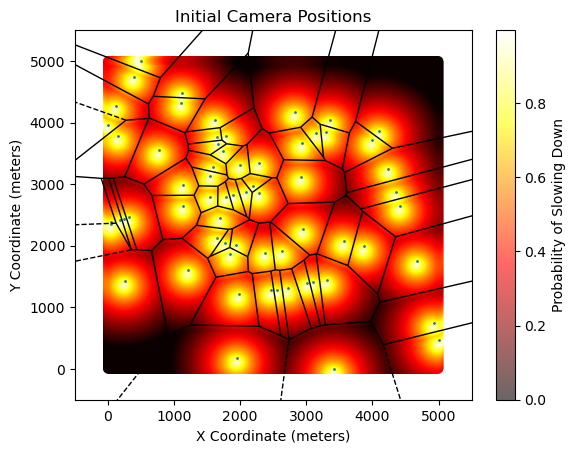

Initial Average Coverage Probability: 0.4264971596581007


<Figure size 1200x800 with 0 Axes>

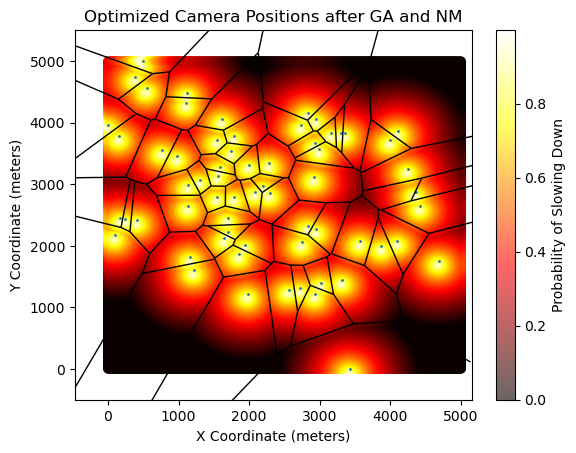

Optimized Average Coverage Probability after GA and NM: 0.5093017287708319

Solution Improvement: 0.1941503413038227
0.021617061722018955

There is a statistically significant difference in the means of the initial and final probabilities.


In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'SANTIAGO']  # Filter for Providencia
provi_df = provi_df[~((provi_df['X'].round(7) == -70.8574927) & (provi_df['Y'].round(7) == -33.609812))]
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 300
num_generations = 500
mutation_base_rate = 0.02
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 10
num_parents = population_size // 2
early_stopping_rounds = 50
no_improvement_stretch = 0
best_fitness = 0

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()
    
# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)



def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = np.random.uniform(0, max(area_size), 2)
    return child


def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=0.4):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0
    num_pairs = 0

    # Calculate the reduction factor for each violating camera pair
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            distance = np.linalg.norm(individual[i] - individual[j])
            if distance < min_distance:
                penalty_reduction = (min_distance - distance) / min_distance
                penalty += penalty_reduction
                num_pairs += 1

    # Calculate average penalty if there are any violations
    if num_pairs > 0:
        average_penalty = penalty / num_pairs
        adjusted_coverage = coverage * (1 - penalty_scale * average_penalty)
    else:
        adjusted_coverage = coverage

    # Ensure fitness is non-negative
    fitness = max(0, adjusted_coverage)
    #print(f"Debug: Original Coverage {coverage}, Penalty {penalty}, Adjusted Coverage {adjusted_coverage}, Final Fitness {fitness}")
    return fitness




def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

# Initialize population
population = initialize_population(population_size, scaled_crash_points)

# Main GA loop
for generation in range(num_generations):
    fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
    current_best = np.max(fitness_scores)
    
    if current_best > best_fitness:
        best_fitness = current_best
        no_improvement_stretch = 0
    else:
        no_improvement_stretch += 1
    
    if no_improvement_stretch >= early_stopping_rounds:
        print(f"Early stopping after {generation} generations.")
        break
    
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

# Determine the best solution
final_fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
best_index = np.argmax(final_fitness_scores)
best_solution = population[best_index]

# Print the final best solution and its fitness
print("Best Solution Fitness:", final_fitness_scores[best_index])

#-----------------------------------------------------------------------------------------------


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

# Record the start time
start_time = time.time()

# Initialize camera positions with scaled crash points
camera_positions = best_solution

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Logarithmic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#Nelder-Mead Optimization after GA----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")

else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")

output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Santiago/Hybrid1_Log_Stgo_Positions.csv'  # Adjust the path as necessary
camera_positions_df.to_csv(output_csv_path, index=False)
output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Santiago/Hybrid1_Log_Stgo_HT.csv'  # Adjust the path as necessary
comparison_df.to_csv(output_csv_path2, index=False)


In [4]:
#Linear

Generation 1, Best Fitness: 0.629726833516711
Generation 2, Best Fitness: 0.6458647383682438
Generation 3, Best Fitness: 0.6458647383682438
Generation 4, Best Fitness: 0.6743561711613147
Generation 5, Best Fitness: 0.6743561711613147
Generation 6, Best Fitness: 0.6743561711613147
Generation 7, Best Fitness: 0.6818520167793131
Generation 8, Best Fitness: 0.6818520167793131
Generation 9, Best Fitness: 0.6831631778059434
Generation 10, Best Fitness: 0.6967594946077886
Generation 11, Best Fitness: 0.6967594946077886
Generation 12, Best Fitness: 0.6982586826707514
Generation 13, Best Fitness: 0.6996331164639178
Generation 14, Best Fitness: 0.7026233534863346
Generation 15, Best Fitness: 0.7026233534863346
Generation 16, Best Fitness: 0.7026233534863346
Generation 17, Best Fitness: 0.7026233534863346
Generation 18, Best Fitness: 0.7026233534863346
Generation 19, Best Fitness: 0.702893580812019
Generation 20, Best Fitness: 0.7063824917844774
Generation 21, Best Fitness: 0.7113129792293577
Gen

<Figure size 1200x800 with 0 Axes>

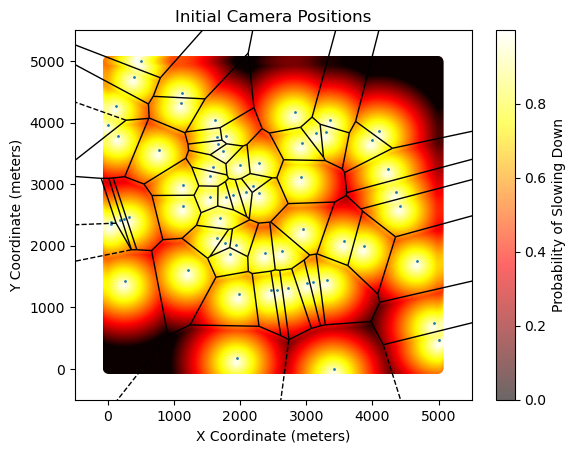

Initial Average Coverage Probability: 0.579662381826946


<Figure size 1200x800 with 0 Axes>

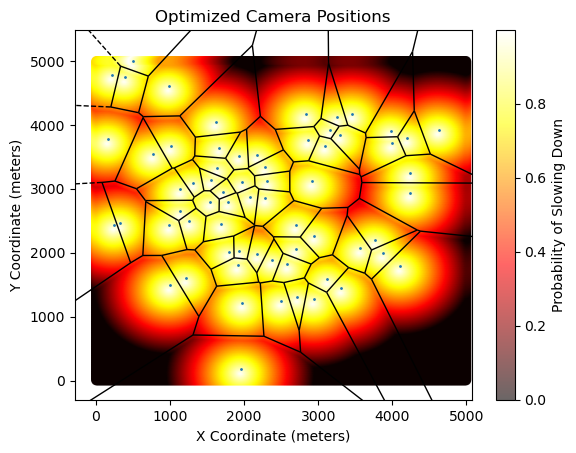

Optimized Average Coverage Probability: 0.6753769827897346

Solution Improvement: 0.16512129122666358


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_4331/4001908703.py:298: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.686079133022022


<Figure size 1200x800 with 0 Axes>

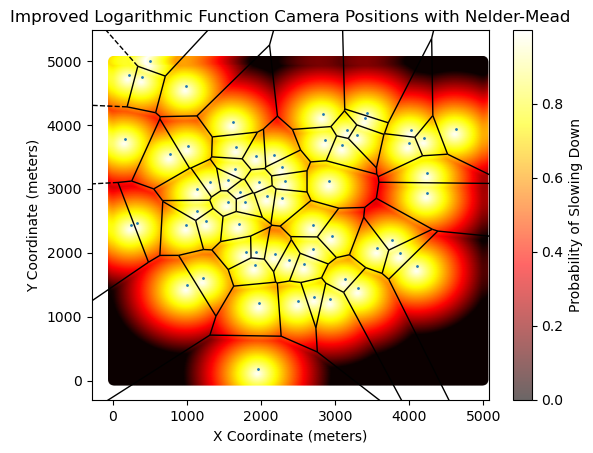

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.65, Y: -33.45)
Camera 2: (X: -70.65, Y: -33.44)
Camera 3: (X: -70.64, Y: -33.44)
Camera 4: (X: -70.66, Y: -33.46)
Camera 5: (X: -70.65, Y: -33.45)
Camera 6: (X: -70.67, Y: -33.44)
Camera 7: (X: -70.65, Y: -33.46)
Camera 8: (X: -70.67, Y: -33.45)
Camera 9: (X: -70.64, Y: -33.44)
Camera 10: (X: -70.67, Y: -33.43)
Camera 11: (X: -70.66, Y: -33.45)
Camera 12: (X: -70.66, Y: -33.44)
Camera 13: (X: -70.63, Y: -33.44)
Camera 14: (X: -70.65, Y: -33.44)
Camera 15: (X: -70.66, Y: -33.43)
Camera 16: (X: -70.64, Y: -33.45)
Camera 17: (X: -70.65, Y: -33.45)
Camera 18: (X: -70.64, Y: -33.43)
Camera 19: (X: -70.67, Y: -33.44)
Camera 20: (X: -70.66, Y: -33.45)
Camera 21: (X: -70.63, Y: -33.44)
Camera 22: (X: -70.64, Y: -33.44)
Camera 23: (X: -70.66, Y: -33.46)
Camera 24: (X: -70.64, Y: -33.46)
Camera 25: (X: -70.67, Y: -33.45)
Camera 26: (X: -70.66, Y: -33.44)
Camera 27: (X: -70.66, Y: -33.44)
Camera 28: (X: -70.65, Y: -33.44)
Camera 29: (X

<Figure size 1200x800 with 0 Axes>

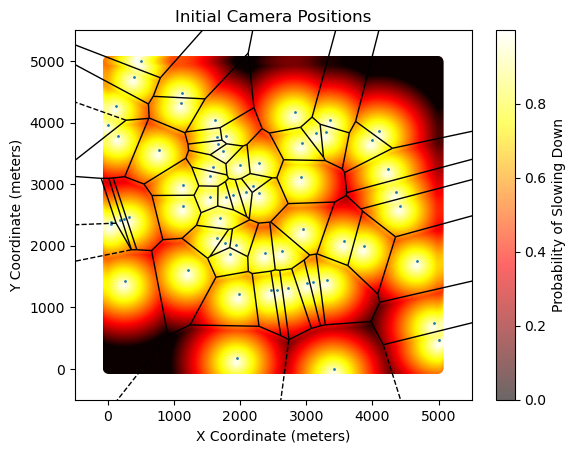

Initial Average Coverage Probability: 0.579662381826946


<Figure size 1200x800 with 0 Axes>

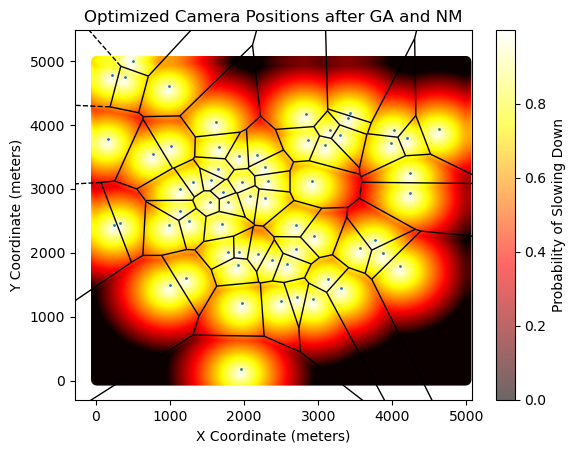

Optimized Average Coverage Probability after GA and NM: 0.686079133022022

Solution Improvement: 0.1835840215466077
0.009386766977332484

There is a statistically significant difference in the means of the initial and final probabilities.


In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'SANTIAGO']  # Filter for Providencia
provi_df = provi_df[~((provi_df['X'].round(7) == -70.8574927) & (provi_df['Y'].round(7) == -33.609812))]
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 300
num_generations = 500
mutation_base_rate = 0.02
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 10
num_parents = population_size // 2
early_stopping_rounds = 50
no_improvement_stretch = 0
best_fitness = 0

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()

# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    # Linear function parameters as solved previously
    a = -1/1000
    b = 1
    probability = a * dist + b
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)



def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = np.random.uniform(0, max(area_size), 2)
    return child


def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=0.4):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0
    num_pairs = 0

    # Calculate the reduction factor for each violating camera pair
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            distance = np.linalg.norm(individual[i] - individual[j])
            if distance < min_distance:
                penalty_reduction = (min_distance - distance) / min_distance
                penalty += penalty_reduction
                num_pairs += 1

    # Calculate average penalty if there are any violations
    if num_pairs > 0:
        average_penalty = penalty / num_pairs
        adjusted_coverage = coverage * (1 - penalty_scale * average_penalty)
    else:
        adjusted_coverage = coverage

    # Ensure fitness is non-negative
    fitness = max(0, adjusted_coverage)
    #print(f"Debug: Original Coverage {coverage}, Penalty {penalty}, Adjusted Coverage {adjusted_coverage}, Final Fitness {fitness}")
    return fitness




def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

# Initialize population
population = initialize_population(population_size, scaled_crash_points)

# Main GA loop
for generation in range(num_generations):
    fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
    current_best = np.max(fitness_scores)
    
    if current_best > best_fitness:
        best_fitness = current_best
        no_improvement_stretch = 0
    else:
        no_improvement_stretch += 1
    
    if no_improvement_stretch >= early_stopping_rounds:
        print(f"Early stopping after {generation} generations.")
        break
    
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

# Determine the best solution
final_fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
best_index = np.argmax(final_fitness_scores)
best_solution = population[best_index]

# Print the final best solution and its fitness
print("Best Solution Fitness:", final_fitness_scores[best_index])

#-----------------------------------------------------------------------------------------------


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

# Record the start time
start_time = time.time()

# Initialize camera positions with scaled crash points
camera_positions = best_solution

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Logarithmic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#Nelder-Mead Optimization after GA----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Santiago/Hybrid1_Lin_Stgo_Positions.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
    output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Santiago/Hybrid1_Lin_Stgo_HT.csv'  # Adjust the path as necessary
    comparison_df.to_csv(output_csv_path2, index=False)

else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")


In [6]:
#Quadratic

Generation 1, Best Fitness: 0.6584192841105745
Generation 2, Best Fitness: 0.6731829691012099
Generation 3, Best Fitness: 0.7077710566153258
Generation 4, Best Fitness: 0.7077710566153258
Generation 5, Best Fitness: 0.7077710566153258
Generation 6, Best Fitness: 0.7098720155334861
Generation 7, Best Fitness: 0.7265662445792932
Generation 8, Best Fitness: 0.7265662445792932
Generation 9, Best Fitness: 0.7305477157613882
Generation 10, Best Fitness: 0.7374851391383012
Generation 11, Best Fitness: 0.7374851391383012
Generation 12, Best Fitness: 0.7387918213087433
Generation 13, Best Fitness: 0.7387918213087433
Generation 14, Best Fitness: 0.7391264659875649
Generation 15, Best Fitness: 0.7406744592297149
Generation 16, Best Fitness: 0.7464714821387021
Generation 17, Best Fitness: 0.7523459246719404
Generation 18, Best Fitness: 0.7523459246719404
Generation 19, Best Fitness: 0.762179099982974
Generation 20, Best Fitness: 0.762179099982974
Generation 21, Best Fitness: 0.7653133864820847
Gen

<Figure size 1200x800 with 0 Axes>

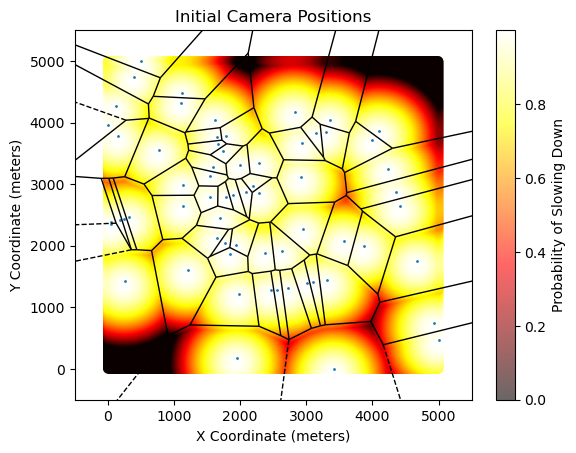

Initial Average Coverage Probability: 0.7380033419441029


<Figure size 1200x800 with 0 Axes>

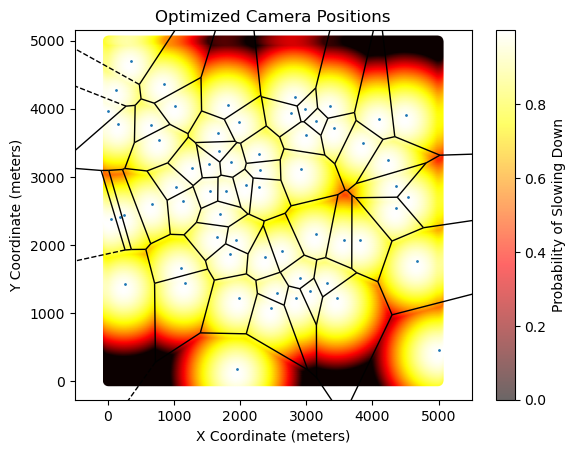

Optimized Average Coverage Probability: 0.8185608700554627

Solution Improvement: 0.10915604785630004


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_4331/61793088.py:297: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.825919836628169


<Figure size 1200x800 with 0 Axes>

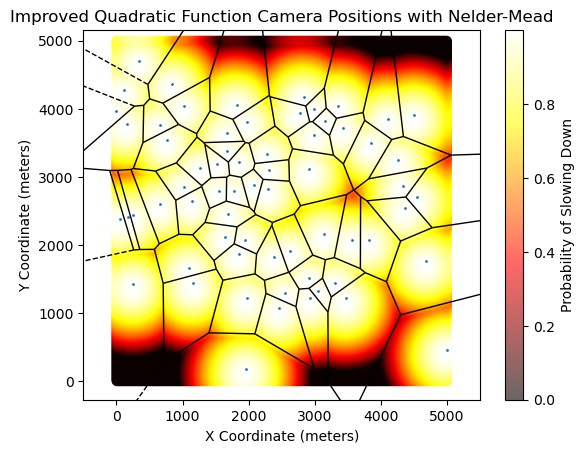

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.67, Y: -33.44)
Camera 2: (X: -70.63, Y: -33.47)
Camera 3: (X: -70.65, Y: -33.46)
Camera 4: (X: -70.66, Y: -33.46)
Camera 5: (X: -70.67, Y: -33.45)
Camera 6: (X: -70.64, Y: -33.44)
Camera 7: (X: -70.66, Y: -33.43)
Camera 8: (X: -70.64, Y: -33.44)
Camera 9: (X: -70.65, Y: -33.46)
Camera 10: (X: -70.66, Y: -33.44)
Camera 11: (X: -70.66, Y: -33.44)
Camera 12: (X: -70.66, Y: -33.45)
Camera 13: (X: -70.66, Y: -33.45)
Camera 14: (X: -70.63, Y: -33.44)
Camera 15: (X: -70.66, Y: -33.44)
Camera 16: (X: -70.64, Y: -33.43)
Camera 17: (X: -70.64, Y: -33.44)
Camera 18: (X: -70.66, Y: -33.44)
Camera 19: (X: -70.66, Y: -33.47)
Camera 20: (X: -70.65, Y: -33.44)
Camera 21: (X: -70.66, Y: -33.45)
Camera 22: (X: -70.65, Y: -33.43)
Camera 23: (X: -70.68, Y: -33.45)
Camera 24: (X: -70.66, Y: -33.45)
Camera 25: (X: -70.65, Y: -33.44)
Camera 26: (X: -70.64, Y: -33.45)
Camera 27: (X: -70.63, Y: -33.45)
Camera 28: (X: -70.66, Y: -33.45)
Camera 29: (X

<Figure size 1200x800 with 0 Axes>

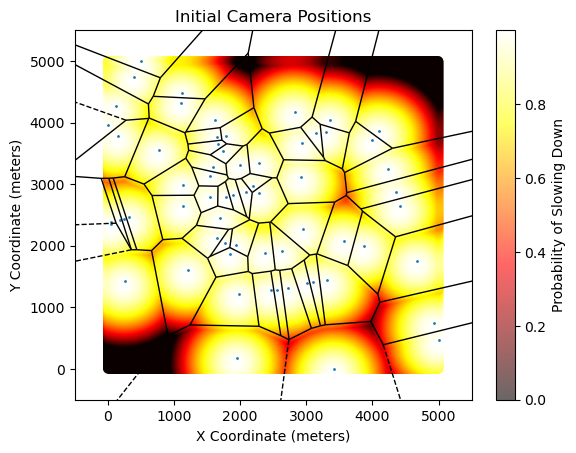

Initial Average Coverage Probability: 0.7380033419441029


<Figure size 1200x800 with 0 Axes>

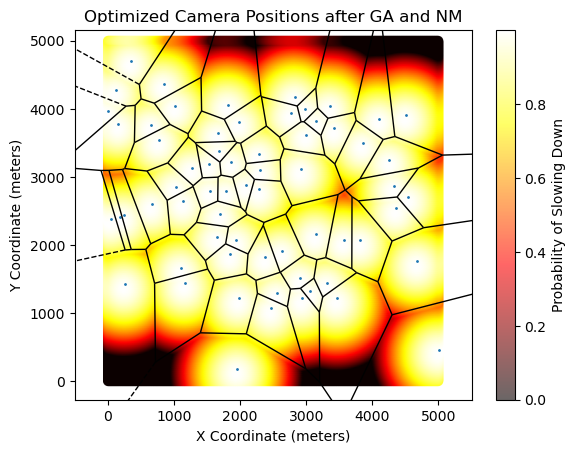

Optimized Average Coverage Probability after GA and NM: 0.825919836628169

Solution Improvement: 0.11912750212278175
0.038611146272931815

There is a statistically significant difference in the means of the initial and final probabilities.


In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'SANTIAGO']  # Filter for Providencia
provi_df = provi_df[~((provi_df['X'].round(7) == -70.8574927) & (provi_df['Y'].round(7) == -33.609812))]
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 300
num_generations = 500
mutation_base_rate = 0.02
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 10
num_parents = population_size // 2
early_stopping_rounds = 50
no_improvement_stretch = 0
best_fitness = 0

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()
    
# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    a = -1/1000**2
    c = 1
    probability = a * dist**2 + c
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)



def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = np.random.uniform(0, max(area_size), 2)
    return child


def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=0.4):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0
    num_pairs = 0

    # Calculate the reduction factor for each violating camera pair
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            distance = np.linalg.norm(individual[i] - individual[j])
            if distance < min_distance:
                penalty_reduction = (min_distance - distance) / min_distance
                penalty += penalty_reduction
                num_pairs += 1

    # Calculate average penalty if there are any violations
    if num_pairs > 0:
        average_penalty = penalty / num_pairs
        adjusted_coverage = coverage * (1 - penalty_scale * average_penalty)
    else:
        adjusted_coverage = coverage

    # Ensure fitness is non-negative
    fitness = max(0, adjusted_coverage)
    #print(f"Debug: Original Coverage {coverage}, Penalty {penalty}, Adjusted Coverage {adjusted_coverage}, Final Fitness {fitness}")
    return fitness




def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

# Initialize population
population = initialize_population(population_size, scaled_crash_points)

# Main GA loop
for generation in range(num_generations):
    fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
    current_best = np.max(fitness_scores)
    
    if current_best > best_fitness:
        best_fitness = current_best
        no_improvement_stretch = 0
    else:
        no_improvement_stretch += 1
    
    if no_improvement_stretch >= early_stopping_rounds:
        print(f"Early stopping after {generation} generations.")
        break
    
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

# Determine the best solution
final_fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
best_index = np.argmax(final_fitness_scores)
best_solution = population[best_index]

# Print the final best solution and its fitness
print("Best Solution Fitness:", final_fitness_scores[best_index])

#-----------------------------------------------------------------------------------------------


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

# Record the start time
start_time = time.time()

# Initialize camera positions with scaled crash points
camera_positions = best_solution

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Quadratic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#Nelder-Mead Optimization after GA----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Santiago/Hybrid1_Quad_Stgo_Positions.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
    output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Santiago/Hybrid1_Quad_Stgo_HT.csv'  # Adjust the path as necessary
    comparison_df.to_csv(output_csv_path2, index=False)

else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")
